### Dependencies

In [27]:
%pip install numpy
%pip install matplotlib
%pip install scipy
%pip install pyod
%pip install scikit-learn
%pip install tensorflow
%pip install keras

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


...


[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [28]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat
from pyod.models.pca import PCA
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import balanced_accuracy_score
from pyod.models.kpca import KPCA
from sklearn.preprocessing import MinMaxScaler
from tensorflow import keras
import tensorflow as tf

In [29]:
import warnings
warnings.filterwarnings('ignore')

In [30]:
import warnings
warnings.filterwarnings('default')

### Exercise 1

X shape: (500, 3)
Eigen Values: [10.40716191  4.11480421  0.3813191 ]
Eigen Vectors Shape: (3, 3)
First Eigen Vector Shape: (3,)


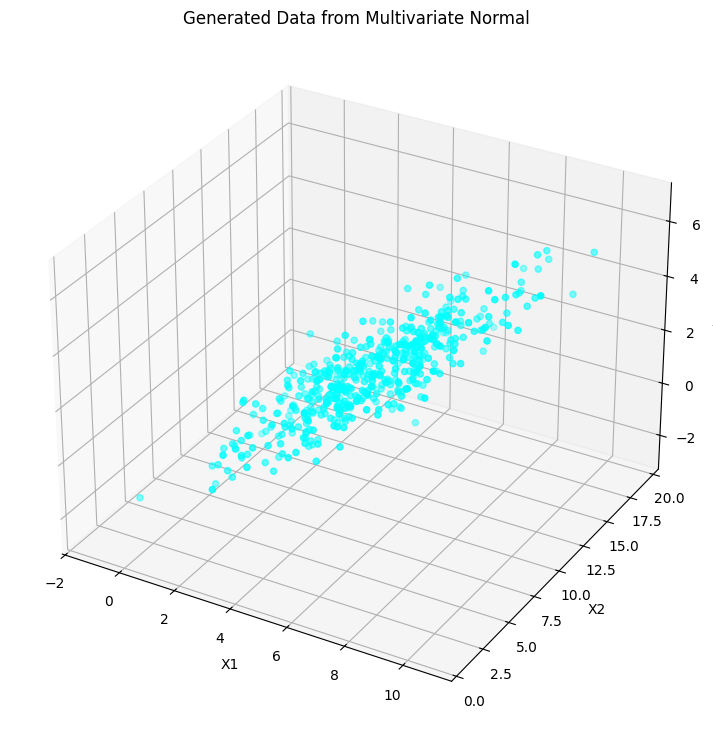

In [31]:
def ex1_1():
    num_samples = 500

    mean = np.array([5.0, 10.0, 2.0])
    covariance = np.array([[3.0, 2.0, 2.0], [2.0, 10.0, 1.0], [2.0, 1.0, 2.0]])

    X = np.random.multivariate_normal(mean=mean, cov=covariance, size=num_samples)
    print(f'X shape: {X.shape}')

    fig = plt.figure(figsize=(12, 9))
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(X[:, 0], X[:, 1], X[:, 2], c='cyan')
    ax.set_title(f'Generated Data from Multivariate Normal')
    ax.set_xlabel('X1')
    ax.set_ylabel('X2')
    ax.set_zlabel('X3')
    # ax.legend()

    X_centered = X - np.mean(X, axis=0)
    covariance_matrix = np.cov(X_centered, rowvar=False)

    eigen_values, eigen_vectors = np.linalg.eig(covariance_matrix)

    print(f'Eigen Values: {eigen_values}')
    print(f'Eigen Vectors Shape: {eigen_vectors.shape}')
    print(f'First Eigen Vector Shape: {eigen_vectors[:, 0].shape}')

    return X, eigen_values, eigen_vectors


X_ex1_1, eigen_values_ex1_1, eigen_vectors_ex1_1 = ex1_1()

Cumulative Explained Variance: [0.69831327 0.97441376 1.        ]


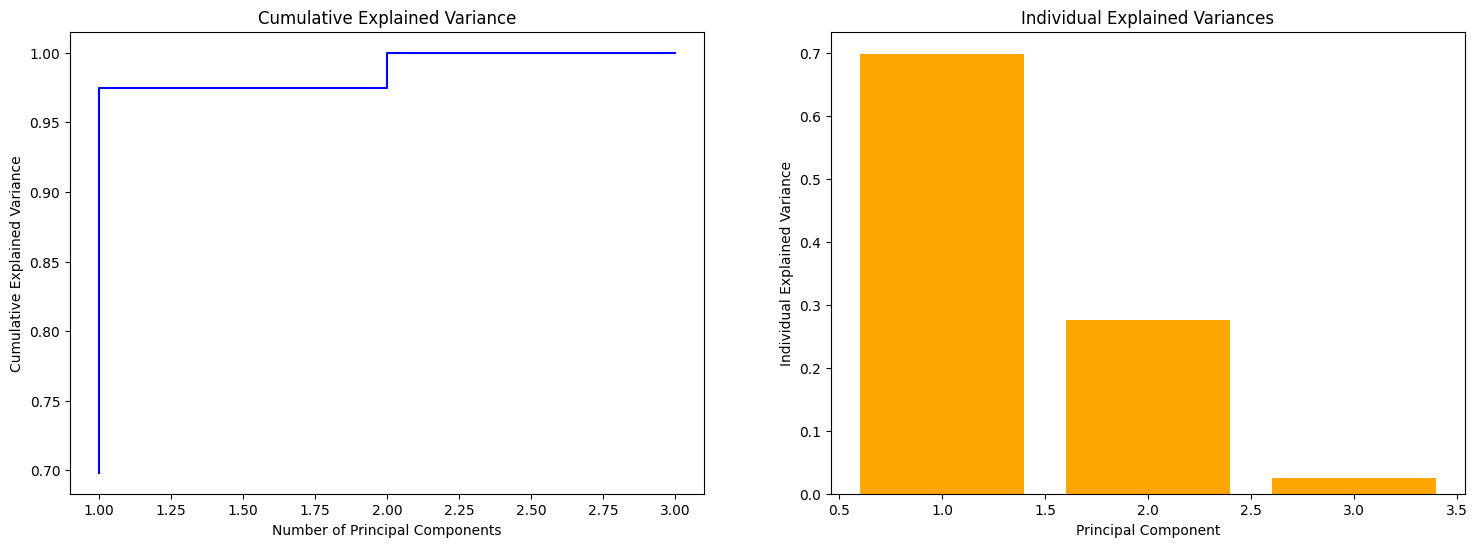

In [32]:
def ex1_2(eigen_values):
    normalized_eigen_values = eigen_values / np.sum(eigen_values)
    sorted_normalized_eigen_values = np.sort(normalized_eigen_values)[::-1]

    cumulative_explained_variance = np.cumsum(sorted_normalized_eigen_values)

    print(f'Cumulative Explained Variance: {cumulative_explained_variance}')

    _, axes = plt.subplots(1, 2, figsize=(18, 6))
    axes = axes.flatten()

    axes[0].step(range(1, len(cumulative_explained_variance) + 1), cumulative_explained_variance, color='blue')
    axes[0].set_title('Cumulative Explained Variance')
    axes[0].set_xlabel('Number of Principal Components')
    axes[0].set_ylabel('Cumulative Explained Variance')
    # axes[0].legend()

    axes[1].bar(range(1, len(normalized_eigen_values) + 1), normalized_eigen_values, color='orange')
    axes[1].set_title('Individual Explained Variances')
    axes[1].set_xlabel('Principal Component')
    axes[1].set_ylabel('Individual Explained Variance')
    # axes[1].legend()

    plt.show()


ex1_2(eigen_values_ex1_1)


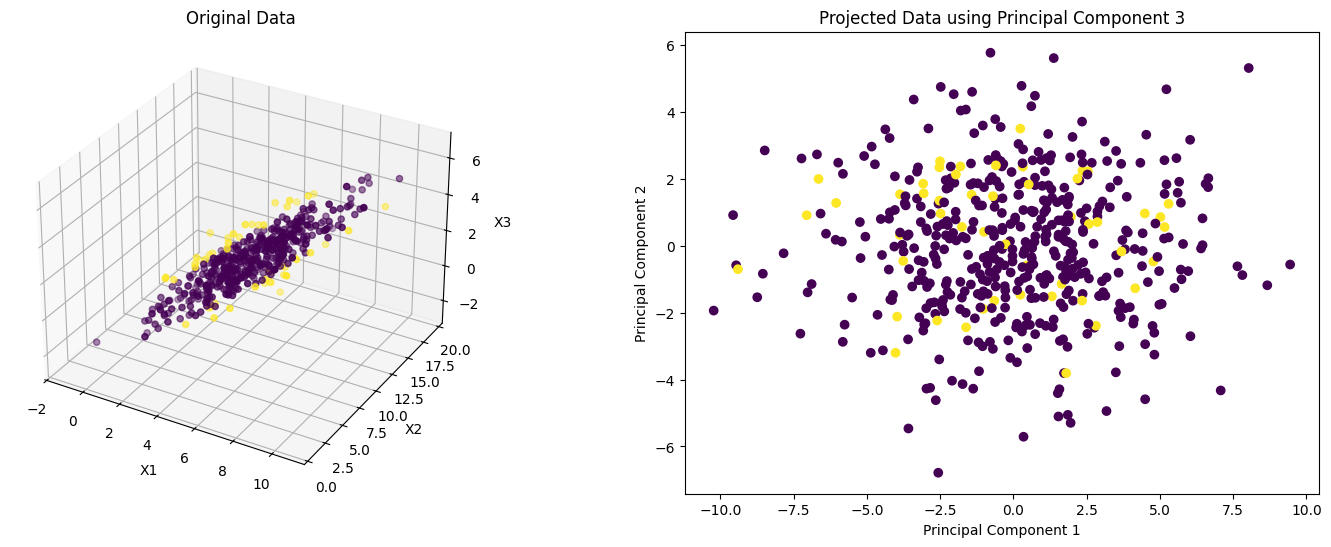

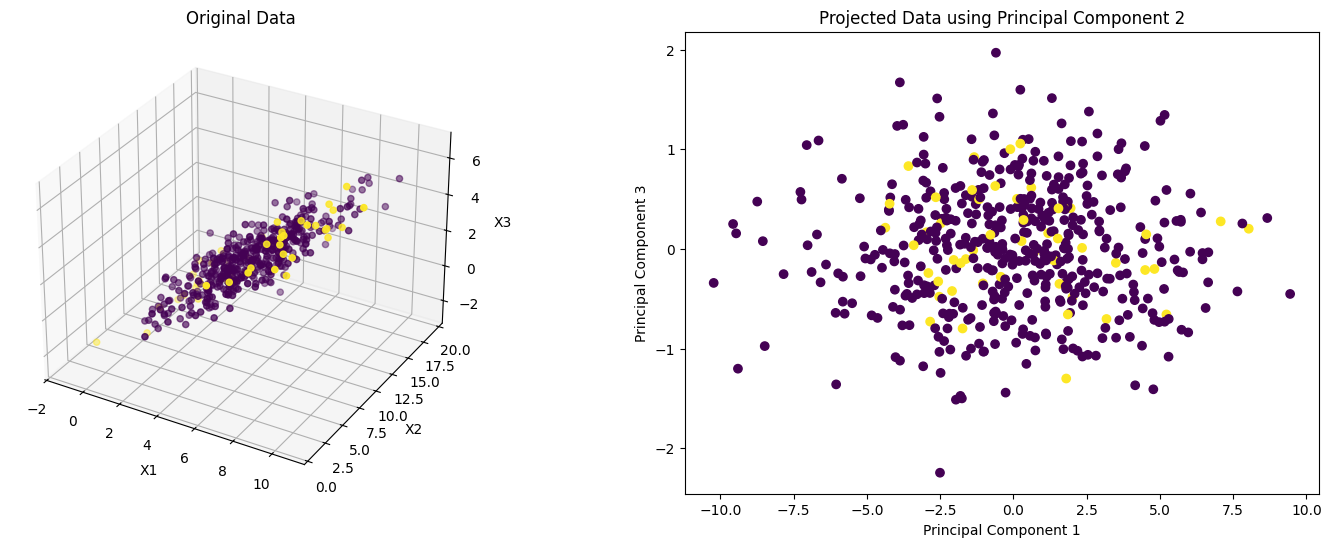

In [33]:
def ex1_3(X, eigen_values, eigen_vectors, idx_principal_component):
    X_centered = X - np.mean(X, axis=0)

    idxs_sorted_eigen_values = np.argsort(eigen_values)[::-1]
    sorted_eigen_values = eigen_values[idxs_sorted_eigen_values]
    sorted_eigen_vectors = eigen_vectors[:, idxs_sorted_eigen_values]

    X_projected = X_centered.dot(sorted_eigen_vectors)
    X_projected_on_principal_component = X_projected[:, idx_principal_component]

    contamination = 0.1
    threshold = np.quantile(np.abs(X_projected_on_principal_component), 1.0 - contamination)
    outliers = (np.abs(X_projected_on_principal_component) > threshold).astype(int)

    fig = plt.figure(figsize=(18, 6))

    ax_0 = fig.add_subplot(1, 2, 1, projection='3d')
    ax_0.scatter(X[:, 0], X[:, 1], X[:, 2], c=outliers)
    ax_0.set_title(f'Original Data')
    ax_0.set_xlabel('X1')
    ax_0.set_ylabel('X2')
    ax_0.set_zlabel('X3')
    # ax_0.legend()

    remaining_dims = [i for i in range(X.shape[1]) if i != idx_principal_component]

    ax_1 = fig.add_subplot(1, 2, 2)
    ax_1.scatter(X_projected[:, remaining_dims[0]], X_projected[:, remaining_dims[1]], c=outliers)
    ax_1.set_title(f'Projected Data using Principal Component {idx_principal_component + 1}')
    ax_1.set_xlabel(f'Principal Component {remaining_dims[0] + 1}')
    ax_1.set_ylabel(f'Principal Component {remaining_dims[1] + 1}')
    # ax_1.legend()

    plt.show()
    

ex1_3(X_ex1_1, eigen_values_ex1_1, eigen_vectors_ex1_1, 2) # 3rd Principal Component
ex1_3(X_ex1_1, eigen_values_ex1_1, eigen_vectors_ex1_1, 1) # 2nd Principal Component

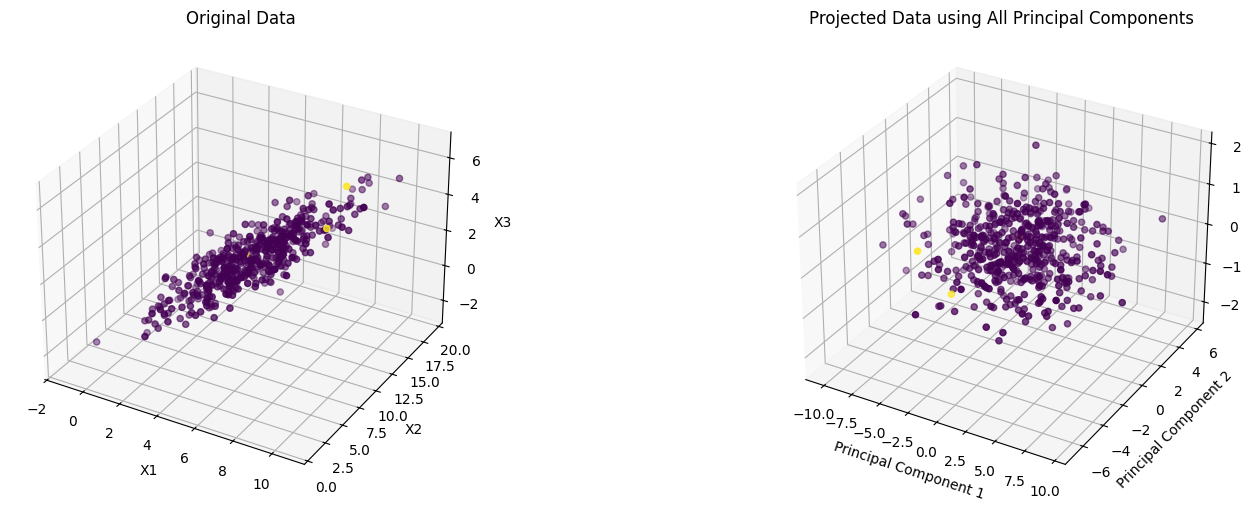

In [34]:
def ex1_4(X, eigen_values, eigen_vectors):
    X_centered = X - np.mean(X, axis=0)

    idxs_sorted_eigen_values = np.argsort(eigen_values)[::-1]
    sorted_eigen_values = eigen_values[idxs_sorted_eigen_values]
    sorted_eigen_vectors = eigen_vectors[:, idxs_sorted_eigen_values]

    X_projected = X_centered.dot(sorted_eigen_vectors)

    mean_X_projected = np.mean(X_projected, axis=0)
    std_X_projected = np.std(X_projected, axis=0)
    X_projected_standardized = (X_projected - mean_X_projected) / std_X_projected
    X_projected_normalized = X_projected_standardized / np.linalg.norm(X_projected_standardized, ord=2, axis=1, keepdims=True)

    contamination = 0.1
    threshold = np.quantile(np.linalg.norm(X_projected_normalized, ord=2, axis=1), 1.0 - contamination)
    outliers = (np.linalg.norm(X_projected_normalized, ord=2, axis=1) > threshold).astype(int)

    fig = plt.figure(figsize=(18, 6))

    ax_0 = fig.add_subplot(1, 2, 1, projection='3d')
    ax_0.scatter(X[:, 0], X[:, 1], X[:, 2], c=outliers)
    ax_0.set_title(f'Original Data')
    ax_0.set_xlabel('X1')
    ax_0.set_ylabel('X2')
    ax_0.set_zlabel('X3')
    # ax_0.legend()

    ax_1 = fig.add_subplot(1, 2, 2, projection='3d')
    ax_1.scatter(X_projected[:, 0], X_projected[:, 1], X_projected[:, 2], c=outliers)
    ax_1.set_title(f'Projected Data using All Principal Components')
    ax_1.set_xlabel(f'Principal Component 1')
    ax_1.set_ylabel(f'Principal Component 2')
    ax_1.set_zlabel(f'Principal Component 3')
    # ax_1.legend()

    plt.show()
    

ex1_4(X_ex1_1, eigen_values_ex1_1, eigen_vectors_ex1_1)

### Exercise 2

In [35]:
def ex2_load_data():
    shuttle_mat = loadmat('shuttle.mat')

    X_shuttle_mat = shuttle_mat['X']
    Y_shuttle_mat = shuttle_mat['y']

    print(f'Loaded shuttle.mat dataset:')
    print(f'X shape: {X_shuttle_mat.shape}')
    print(f'Y shape: {Y_shuttle_mat.shape}')

    train_percentage = 0.6
    X_train, X_test, Y_train, Y_test = train_test_split(X_shuttle_mat, Y_shuttle_mat, train_size=train_percentage, random_state=23)

    standard_scaler = StandardScaler()
    standard_scaler.fit(X_train)
    X_train = standard_scaler.transform(X_train)
    X_test = standard_scaler.transform(X_test)

    train_contamination = np.sum(Y_train == 1) / len(Y_train)
    print(f'Train Contamination: {train_contamination}')

    return X_train, Y_train, X_test, Y_test, train_contamination


X_train_ex2, Y_train_ex2, X_test_ex2, Y_test_ex2, train_contamination_ex2 = ex2_load_data()

Loaded shuttle.mat dataset:
X shape: (49097, 9)
Y shape: (49097, 1)
Train Contamination: 0.07006585647362347


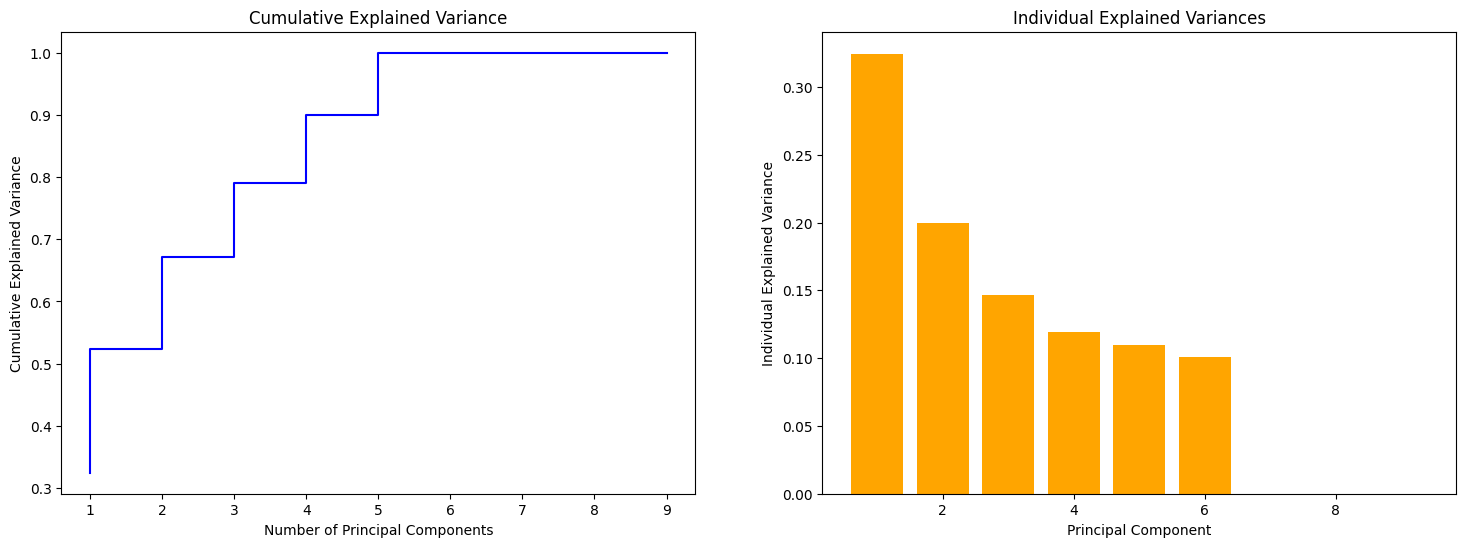

In [36]:
def ex2_1(X_train, Y_train, X_test, Y_test, train_contamination):
    pca = PCA(contamination=train_contamination)
    pca.fit(X_train)

    explained_variances = pca.explained_variance_
    normalized_explained_variances = explained_variances / np.sum(explained_variances)
    cumulative_explained_variance = np.cumsum(normalized_explained_variances)

    _, axes = plt.subplots(1, 2, figsize=(18, 6))
    axes = axes.flatten()

    axes[0].step(range(1, len(cumulative_explained_variance) + 1), cumulative_explained_variance, color='blue')
    axes[0].set_title('Cumulative Explained Variance')
    axes[0].set_xlabel('Number of Principal Components')
    axes[0].set_ylabel('Cumulative Explained Variance')
    # axes[0].legend()

    axes[1].bar(range(1, len(normalized_explained_variances) + 1), normalized_explained_variances, color='orange')
    axes[1].set_title('Individual Explained Variances')
    axes[1].set_xlabel('Principal Component')
    axes[1].set_ylabel('Individual Explained Variance')
    # axes[1].legend()

    plt.show()


ex2_1(X_train_ex2, Y_train_ex2, X_test_ex2, Y_test_ex2, train_contamination_ex2)

In [ ]:
def ex2_2(X_train, Y_train, X_test, Y_test, train_contamination):
    pca = PCA(contamination=train_contamination)
    pca.fit(X_train)

    pca_Y_train_pred = pca.predict(X_train)
    pca_Y_test_pred = pca.predict(X_test)

    pca_train_balanced_accuracy = balanced_accuracy_score(Y_train, pca_Y_train_pred)
    pca_test_balanced_accuracy = balanced_accuracy_score(Y_test, pca_Y_test_pred)

    print(f'PCA Train Balanced Accuracy: {pca_train_balanced_accuracy}')
    print(f'PCA Test Balanced Accuracy: {pca_test_balanced_accuracy}')

    kpca = KPCA(contamination=train_contamination)
    kpca.fit(X_train)

    kpca_Y_train_pred = kpca.predict(X_train)
    kpca_Y_test_pred = kpca.predict(X_test)

    kpca_train_balanced_accuracy = balanced_accuracy_score(Y_train, kpca_Y_train_pred)
    kpca_test_balanced_accuracy = balanced_accuracy_score(Y_test, kpca_Y_test_pred)

    print(f'KPCA Train Balanced Accuracy: {kpca_train_balanced_accuracy}')
    print(f'KPCA Test Balanced Accuracy: {kpca_test_balanced_accuracy}')


ex2_2(X_train_ex2, Y_train_ex2, X_test_ex2, Y_test_ex2, train_contamination_ex2)

c:\Master\Homework-Anomaly-Detection-AD\Laboratories\.venv\Lib\site-packages\sklearn\utils\_tags.py:338: DeprecationWarning: The following error was raised: 'PCA' object has no attribute '__sklearn_tags__'. It seems that there are no classes that implement `__sklearn_tags__` in the MRO and/or all classes in the MRO call `super().__sklearn_tags__()`. Make sure to inherit from `BaseEstimator` which implements `__sklearn_tags__` (or alternatively define `__sklearn_tags__` but we don't recommend this approach). Note that `BaseEstimator` needs to be on the right side of other Mixins in the inheritance order. The default are now used instead since retrieving tags failed. This warning will be replaced by an error in 1.8.
  warnings.warn(
c:\Master\Homework-Anomaly-Detection-AD\Laboratories\.venv\Lib\site-packages\sklearn\utils\_tags.py:338: DeprecationWarning: The following error was raised: 'PCA' object has no attribute '__sklearn_tags__'. It seems that there are no classes that implement `_

PCA Train Balanced Accuracy: 0.9718659747254109
PCA Test Balanced Accuracy: 0.9762244459619545


### Exercise 3

In [37]:
def ex3_load_data():
    shuttle_mat = loadmat('shuttle.mat')

    X_shuttle_mat = shuttle_mat['X']
    Y_shuttle_mat = shuttle_mat['y']

    print(f'Loaded shuttle.mat dataset:')
    print(f'X shape: {X_shuttle_mat.shape}')
    print(f'Y shape: {Y_shuttle_mat.shape}')

    test_percentage = 0.5
    X_train, X_test, Y_train, Y_test = train_test_split(X_shuttle_mat, Y_shuttle_mat, test_size=test_percentage, random_state=23)

    minmax_scaler = MinMaxScaler()
    minmax_scaler.fit(X_train)
    X_train = minmax_scaler.transform(X_train)
    X_test = minmax_scaler.transform(X_test)

    train_contamination = np.sum(Y_train == 1) / len(Y_train)
    print(f'Train Contamination: {train_contamination}')

    return X_train, Y_train, X_test, Y_test, train_contamination


X_train_ex3, Y_train_ex3, X_test_ex3, Y_test_ex3, train_contamination_ex3 = ex3_load_data()

Loaded shuttle.mat dataset:
X shape: (49097, 9)
Y shape: (49097, 1)
Train Contamination: 0.06986312530552387


In [38]:
class AutoEncoder(keras.Model):
    def __init__(self, num_features):
        super(AutoEncoder, self).__init__()

        self.encoder = keras.Sequential(
            [
                keras.layers.Dense(8, activation='relu', input_shape=(num_features,)),
                keras.layers.Dense(5, activation='relu'),
                keras.layers.Dense(3, activation='relu')
            ]
        )

        self.decoder = keras.Sequential(
            [
                keras.layers.Dense(5, activation='relu', input_shape=(3,)),
                keras.layers.Dense(8, activation='relu'),
                keras.layers.Dense(num_features, activation='sigmoid') # num_features = 9
            ]
        )


    def call(self, X):
        X_encoded = self.encoder(X)
        X_decoded = self.decoder(X_encoded)

        return X_decoded

Epoch 1/100


c:\Master\Homework-Anomaly-Detection-AD\Laboratories\.venv\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
c:\Master\Homework-Anomaly-Detection-AD\Laboratories\.venv\Lib\site-packages\keras\src\backend\tensorflow\core.py:171: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  return np.array(x)


24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0223 - val_loss: 0.0219
Epoch 2/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0212 - val_loss: 0.0208
Epoch 3/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0201 - val_loss: 0.0197
Epoch 4/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0191 - val_loss: 0.0188
Epoch 5/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0181 - val_loss: 0.0179
Epoch 6/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0173 - val_loss: 0.0170
Epoch 7/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0164 - val_loss: 0.0162
Epoch 8/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0156 - val_loss: 0.0154
Epoch 9/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0149 - val_loss: 0.0147
Epoch 10/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0142 - val_loss: 0.0141
Epoch 11/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0136 - val_loss: 0.0134
Epoch 12/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0130 - val_l

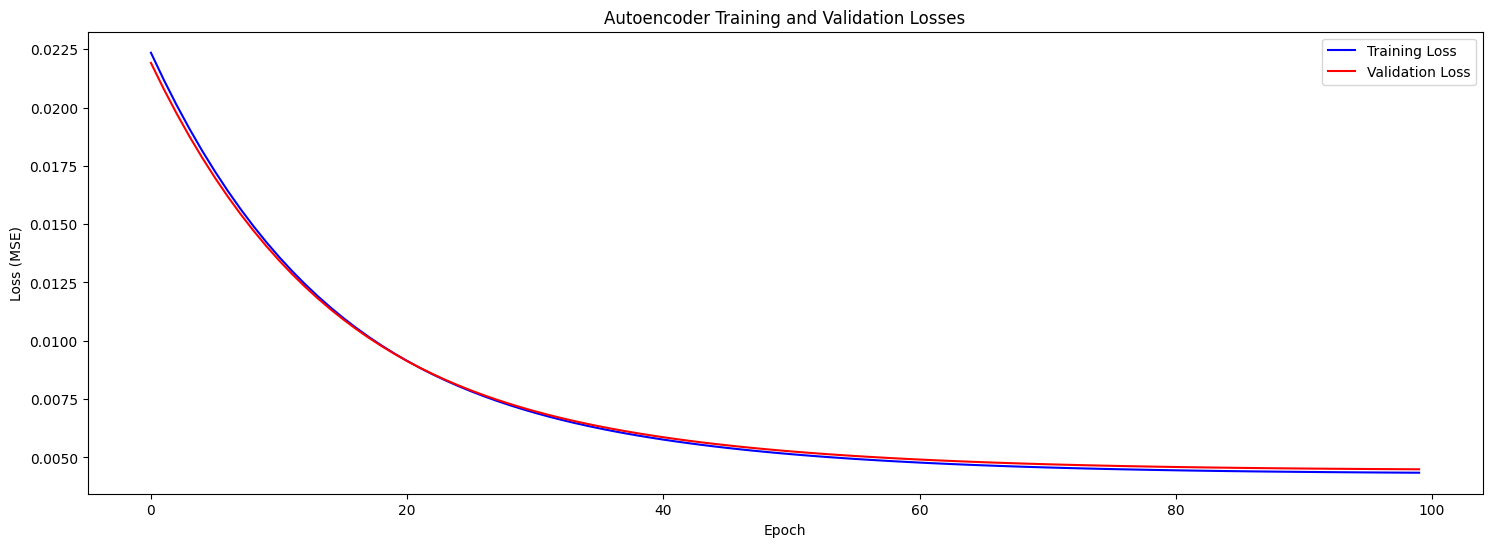

768/768 ━━━━━━━━━━━━━━━━━━━━ 1s 961us/step
768/768 ━━━━━━━━━━━━━━━━━━━━ 1s 779us/step
NumPy Quantile Threshold: 0.011135546599770181
Autoencoder Train Balanced Accuracy: 0.9705363279760165
Autoencoder Test Balanced Accuracy: 0.976028920340126


In [40]:
def ex3_1(X_train, Y_train, X_test, Y_test, train_contamination):
    num_features = X_train.shape[1]
    autoencoder = AutoEncoder(num_features=num_features)

    autoencoder.compile(optimizer='adam', loss='mse')

    metadata = autoencoder.fit(X_train, X_train,
                               epochs=100,
                               batch_size=1024,
                               validation_data=(X_test, X_test),
                               verbose=1)
    
    _, ax = plt.subplots(figsize=(18, 6))

    ax.plot(metadata.history['loss'], label='Training Loss', color='blue')
    ax.plot(metadata.history['val_loss'], label='Validation Loss', color='red')
    ax.set_title('Autoencoder Training and Validation Losses')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss (MSE)')
    ax.legend()

    plt.show()

    X_train_pred = autoencoder.predict(X_train)
    train_reconstruction_error = np.mean(np.power(X_train - X_train_pred, 2), axis=1)

    X_test_pred = autoencoder.predict(X_test)
    test_reconstruction_error = np.mean(np.power(X_test - X_test_pred, 2), axis=1)

    threshold = np.quantile(train_reconstruction_error, 1.0 - train_contamination)
    print(f'NumPy Quantile Threshold: {threshold}')

    Y_train_pred = (train_reconstruction_error > threshold).astype(int)
    Y_test_pred = (test_reconstruction_error > threshold).astype(int)

    train_balanced_accuracy = balanced_accuracy_score(Y_train, Y_train_pred)
    test_balanced_accuracy = balanced_accuracy_score(Y_test, Y_test_pred)

    print(f'Autoencoder Train Balanced Accuracy: {train_balanced_accuracy}')
    print(f'Autoencoder Test Balanced Accuracy: {test_balanced_accuracy}')


ex3_1(X_train_ex3, Y_train_ex3, X_test_ex3, Y_test_ex3, train_contamination_ex3)


### Exercise 4

In [41]:
def ex4_load_data():
    (X_train, _), (X_test, _) = keras.datasets.mnist.load_data()

    X_train = np.expand_dims(X_train, axis=-1)
    X_test = np.expand_dims(X_test, axis=-1)

    X_train = X_train.astype('float64') / 255.0
    X_test = X_test.astype('float64') / 255.0

    train_noise = tf.random.normal(shape=X_train.shape, mean=0.0, stddev=0.35)
    X_train_noisy = X_train + train_noise
    X_train_noisy = tf.clip_by_value(X_train_noisy, clip_value_min=0.0, clip_value_max=1.0)

    test_noise = tf.random.normal(shape=X_test.shape, mean=0.0, stddev=0.35)
    X_test_noisy = X_test + test_noise
    X_test_noisy = tf.clip_by_value(X_test_noisy, clip_value_min=0.0, clip_value_max=1.0)

    return X_train, X_train_noisy, X_test, X_test_noisy


X_train_ex4, X_train_noisy_ex4, X_test_ex4, X_test_noisy_ex4 = ex4_load_data()

In [42]:
class ConvolutionalAutoEncoder(keras.Model):
    def __init__(self, num_features):
        super(ConvolutionalAutoEncoder, self).__init__()

        self.encoder = keras.Sequential([
            keras.layers.Conv2D(8, (3, 3), activation='relu', strides=2, padding='same', input_shape=num_features),
            keras.layers.Conv2D(4, (3, 3), activation='relu', strides=2, padding='same')
        ])

        self.decoder = keras.Sequential([
            keras.layers.Conv2DTranspose(4, (3, 3), activation='relu', strides=2, padding='same', input_shape=(7, 7, 4)),
            keras.layers.Conv2DTranspose(8, (3, 3), activation='relu', strides=2, padding='same'),
            keras.layers.Conv2D(1, (3, 3), activation='sigmoid', padding='same')
        ])

    def call(self, X):
        X_encoded = self.encoder(X)
        X_decoded = self.decoder(X_encoded)

        return X_decoded

c:\Master\Homework-Anomaly-Detection-AD\Laboratories\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
c:\Master\Homework-Anomaly-Detection-AD\Laboratories\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv_transpose.py:94: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(


Epoch 1/10


c:\Master\Homework-Anomaly-Detection-AD\Laboratories\.venv\Lib\site-packages\keras\src\backend\tensorflow\core.py:171: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  return np.array(x)


938/938 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - loss: 0.0390 - val_loss: 0.0071
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - loss: 0.0049 - val_loss: 0.0036
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 0.0033 - val_loss: 0.0029
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 0.0029 - val_loss: 0.0026
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 0.0026 - val_loss: 0.0025
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 0.0025 - val_loss: 0.0024
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 0.0024 - val_loss: 0.0023
Epoch 8/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 0.0024 - val_loss: 0.0022
Epoch 9/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 0.0023 - val_loss: 0.0022
Epoch 10/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 0.0023 - val_loss: 0.0022
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Convolutional AutoEncoder

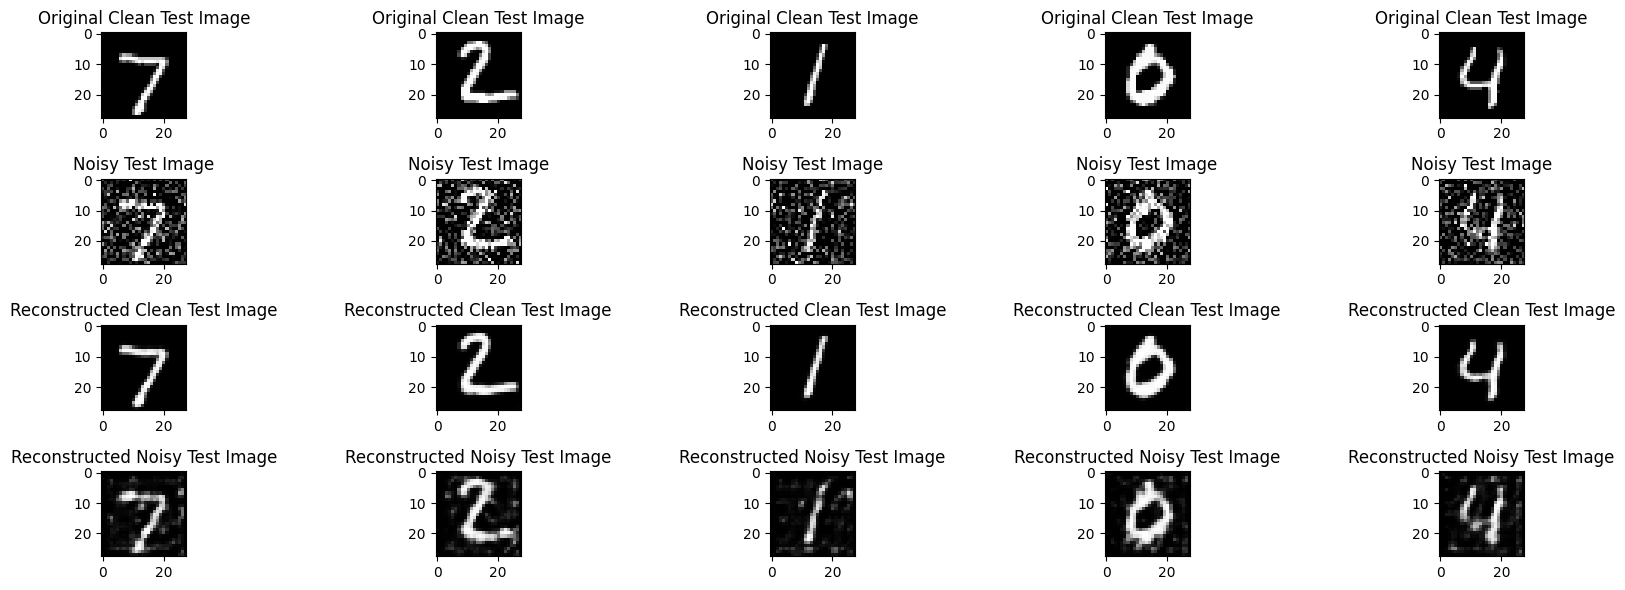

In [43]:
def ex4_3(X_train, X_train_noisy, X_test, X_test_noisy):
    num_features = X_train.shape[1:] # (28, 28, 1)
    convolutional_autoencoder = ConvolutionalAutoEncoder(num_features=num_features)

    convolutional_autoencoder.compile(optimizer='adam', loss='mse')

    metadata = convolutional_autoencoder.fit(X_train, X_train,
                                             epochs=10,
                                             batch_size=64,
                                             validation_data=(X_test, X_test),
                                             verbose=1)
    
    X_train_pred = convolutional_autoencoder.predict(X_train)
    train_reconstruction_error = np.mean(np.power(X_train - X_train_pred, 2), axis=(1, 2, 3))

    mean_train_reconstruction_error = np.mean(train_reconstruction_error)
    std_train_reconstruction_error = np.std(train_reconstruction_error)

    threshold = mean_train_reconstruction_error + std_train_reconstruction_error

    X_test_pred = convolutional_autoencoder.predict(X_test)
    test_reconstruction_error = np.mean(np.power(X_test - X_test_pred, 2), axis=(1, 2, 3))

    Y_test_pred = (test_reconstruction_error > threshold).astype(int)

    X_test_noisy_pred = convolutional_autoencoder.predict(X_test_noisy)
    test_noisy_reconstruction_error = np.mean(np.power(X_test_noisy - X_test_noisy_pred, 2), axis=(1, 2, 3))

    Y_test_noisy_pred = (test_noisy_reconstruction_error > threshold).astype(int)

    accuracy_Y_test = np.mean((Y_test_pred == 0).astype(int))
    accuracy_Y_test_noisy = np.mean((Y_test_noisy_pred == 1).astype(int))

    print(f'Convolutional AutoEncoder Test Accuracy on Clean Data: {accuracy_Y_test}')
    print(f'Convolutional AutoEncoder Test Accuracy on Noisy Data: {accuracy_Y_test_noisy}')

    num_test_images = 5
    _, axes = plt.subplots(4, num_test_images, figsize=(18, 6))
    for i in range(num_test_images):
        axes[0, i].imshow(X_test[i].squeeze(), cmap='gray')
        axes[0, i].set_title('Original Clean Test Image')

        axes[1, i].imshow(X_test_noisy[i].numpy().squeeze(), cmap='gray')
        axes[1, i].set_title('Noisy Test Image')

        axes[2, i].imshow(X_test_pred[i].squeeze(), cmap='gray')
        axes[2, i].set_title('Reconstructed Clean Test Image')

        axes[3, i].imshow(X_test_noisy_pred[i].squeeze(), cmap='gray')
        axes[3, i].set_title('Reconstructed Noisy Test Image')

    plt.tight_layout()
    plt.show()


ex4_3(X_train_ex4, X_train_noisy_ex4, X_test_ex4, X_test_noisy_ex4)

Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - loss: 0.0483 - val_loss: 0.0130
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - loss: 0.0119 - val_loss: 0.0108
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 0.0105 - val_loss: 0.0100
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - loss: 0.0100 - val_loss: 0.0096
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 0.0097 - val_loss: 0.0094
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 13s 14ms/step - loss: 0.0095 - val_loss: 0.0093
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - loss: 0.0093 - val_loss: 0.0091
Epoch 8/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 0.0092 - val_loss: 0.0090
Epoch 9/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 0.0091 - val_loss: 0.0089
Epoch 10/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - loss: 0.0090 - val_loss: 0.0088
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Convolu

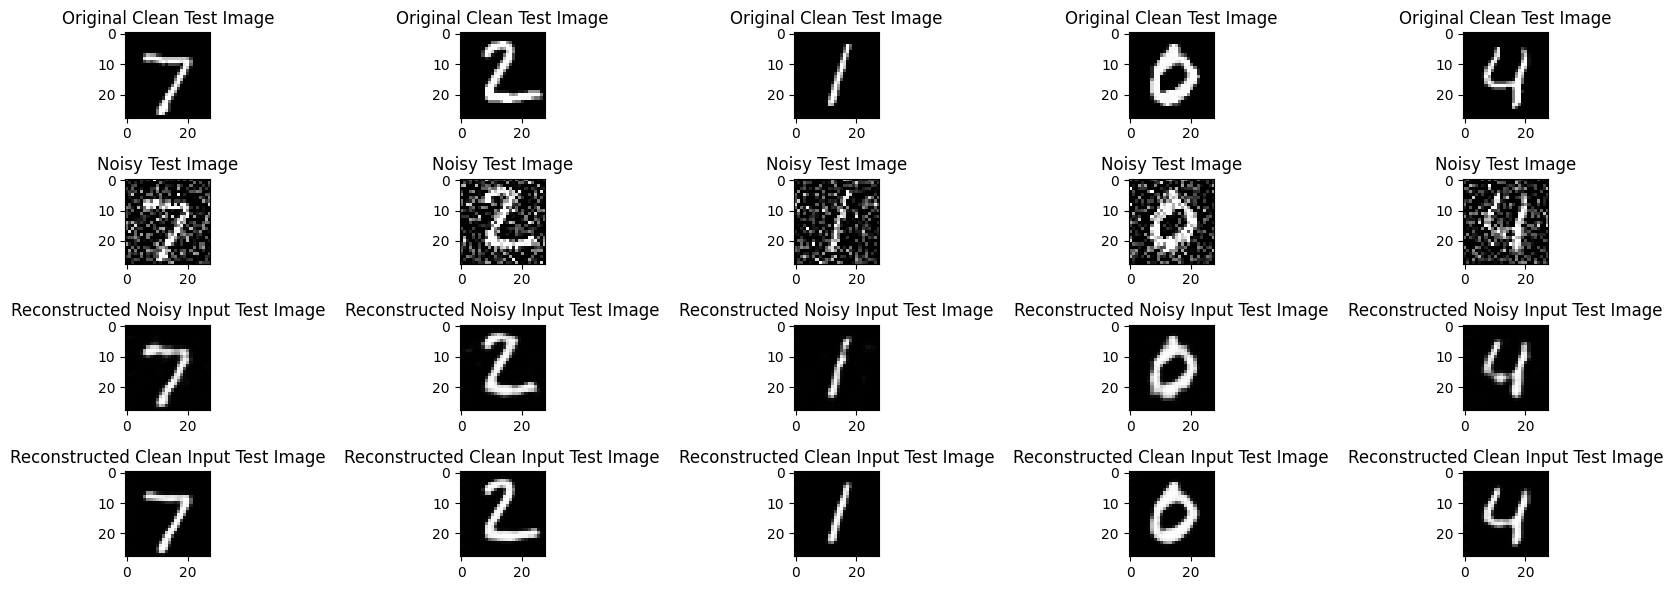

In [47]:
def ex4_5(X_train, X_train_noisy, X_test, X_test_noisy):
    num_features = X_train_noisy.shape[1:] # (28, 28, 1)
    convolutional_autoencoder = ConvolutionalAutoEncoder(num_features=num_features)

    convolutional_autoencoder.compile(optimizer='adam', loss='mse')

    metadata = convolutional_autoencoder.fit(X_train_noisy, X_train,
                                             epochs=10,
                                             batch_size=64,
                                             validation_data=(X_test_noisy, X_test),
                                             verbose=1)
    
    X_train_pred = convolutional_autoencoder.predict(X_train_noisy)
    train_reconstruction_error = np.mean(np.power(X_train - X_train_pred, 2), axis=(1, 2, 3))

    mean_train_reconstruction_error = np.mean(train_reconstruction_error)
    std_train_reconstruction_error = np.std(train_reconstruction_error)

    threshold = mean_train_reconstruction_error + std_train_reconstruction_error

    X_test_pred = convolutional_autoencoder.predict(X_test_noisy)
    test_reconstruction_error = np.mean(np.power(X_test - X_test_pred, 2), axis=(1, 2, 3))

    Y_test_pred = (test_reconstruction_error > threshold).astype(int)

    X_test_clean_input_pred = convolutional_autoencoder.predict(X_test)
    test_clean_input_reconstruction_error = np.mean(np.power(X_test - X_test_clean_input_pred, 2), axis=(1, 2, 3))

    Y_test_clean_input_pred = (test_clean_input_reconstruction_error > threshold).astype(int)

    accuracy_Y_test = np.mean((Y_test_pred == 0).astype(int))
    accuracy_Y_test_clean_input = np.mean((Y_test_clean_input_pred == 1).astype(int))

    print(f'Convolutional (Denoising) AutoEncoder Test Accuracy on Noisy Data: {accuracy_Y_test}')
    print(f'Convolutional (Denoising) AutoEncoder Test Accuracy on Clean Data: {accuracy_Y_test_clean_input}')

    num_test_images = 5
    _, axes = plt.subplots(4, num_test_images, figsize=(18, 6))
    for i in range(num_test_images):
        axes[0, i].imshow(X_test[i].squeeze(), cmap='gray')
        axes[0, i].set_title('Original Clean Test Image')

        axes[1, i].imshow(X_test_noisy[i].numpy().squeeze(), cmap='gray')
        axes[1, i].set_title('Noisy Test Image')

        axes[2, i].imshow(X_test_pred[i].squeeze(), cmap='gray')
        axes[2, i].set_title('Reconstructed Noisy Input Test Image')

        axes[3, i].imshow(X_test_clean_input_pred[i].squeeze(), cmap='gray')
        axes[3, i].set_title('Reconstructed Clean Input Test Image')

    plt.tight_layout()
    plt.show()


ex4_5(X_train_ex4, X_train_noisy_ex4, X_test_ex4, X_test_noisy_ex4)